# 시각 AI 웹 서비스 통합 완료 및 피드백 반영

**Conveyor Visual RAG**(센서·영상)와 **MVTec AD 검사 서비스**를 하나의 실습 흐름으로 통합하고,
**피드백 수집·반영** 루프와 **센서·영상 데이터 연계 테스트**를 수행합니다.

> **선행 학습**: `04_visual_qa_service_streamlit.ipynb` · `07_mvtec_web_service.ipynb` · `08_mvtec_retrieval_evaluation.ipynb`

## 전체 흐름

```
04·07 노트북 (Conveyor API:8000 + MVTec API:8002 + Streamlit)
       ↓
듀얼 서비스 헬스체크 · 포트·벡터 DB 상태 점검
       ↓
센서·영상 통합 테스트 (frame ↔ sensor.csv ↔ ChromaDB)
       ↓
API 엔드투엔드 체크리스트 (검색·조회·통계)
       ↓
사용자 피드백 수집 → JSON 저장 → 개선 권고 반영
       ↓
통합 시나리오 · Streamlit 2종 동시 운영
```

| 서비스 | API | Streamlit | 데이터 |
|--------|-----|-----------|--------|
| **Conveyor VQA** | `:8000` | `conveyor_analyze/dashboard/streamlit_app.py` | 프레임·sensor.csv·ChromaDB |
| **MVTec 검사** | `:8002` | `mvtec_analyze/dashboard/streamlit_app.py` | MVTec test·SQLite·ChromaDB |
| **피드백** | — | — | `data/integration/service_feedback.json` |


### 모듈·UI 참조

📄 **[00_모듈_참조.md](00_모듈_참조.md)**

| 구성요소 | 경로 |
|----------|------|
| Conveyor API·Streamlit | `conveyor_analyze/api/main.py` · `dashboard/streamlit_app.py` |
| MVTec API·Streamlit | `mvtec_analyze/api/main.py` · `dashboard/streamlit_app.py` |
| 센서·영상 연계 | `conveyor_analyze/conveyor_rag/metadata_link.py` |
| 검색 성능 평가 | `08_mvtec_retrieval_evaluation.ipynb` |


## 0. 환경 설정

**사전 준비**
<br>
1. `02` 노트북 — `data/conveyor/frames`, `sensor.csv`, ChromaDB<br>
2. `06` 노트북 — `data/mvtec/inspections.db`, ChromaDB<br>
3. `pip install -r conveyor_analyze/requirements.txt` 및 `mvtec_analyze/requirements.txt`<br>

> **Colab 실행 불가** — 로컬에서 API 2종(8000·8002) + Streamlit 별도 터미널 실행


In [1]:
# !pip install -r conveyor_analyze/requirements.txt
# Conveyor VQA — SigLIP2, ChromaDB, FastAPI, Streamlit 등
# !pip install -r mvtec_analyze/requirements.txt
# MVTec 검사 — SQLite, ChromaDB, Qwen3-VL 연동 패키지

In [2]:
import json
import socket
import subprocess
import sys
import time
import uuid
from datetime import datetime, timezone
from pathlib import Path

import matplotlib.pyplot as plt  # 센서 추이·피드백 평점 차트
import pandas as pd  # 통합 상태표·체크리스트·피드백 집계
import requests  # Conveyor·MVTec FastAPI HTTP 호출
from IPython.display import Markdown, display
from PIL import Image  # Fault 프레임 썸네일 표시

# --- Conveyor 데이터 경로 (02 노트북 산출물) ---
ROOT = Path(".").resolve()
CONVEYOR_DATA = ROOT / "data" / "conveyor"
FRAMES_DIR = CONVEYOR_DATA / "frames"           # OpenCV 추출 영상 프레임
SENSOR_CSV = CONVEYOR_DATA / "sensor.csv"       # 프레임별 temp·rpm·vibration·status
VIDEO_META = CONVEYOR_DATA / "video" / "extracted" / "meta.json"  # 영상 어노테이션 메타

# --- MVTec 데이터 경로 (06 노트북 산출물) ---
MVTEC_DATA = ROOT / "data" / "mvtec"
MVTEC_DB = MVTEC_DATA / "inspections.db"        # SQLite 검사 이력

# --- 패키지·UI 소스 루트 ---
CONVEYOR_ANALYZE = ROOT / "conveyor_analyze"
MVTEC_ANALYZE = ROOT / "mvtec_analyze"
CONVEYOR_STREAMLIT = CONVEYOR_ANALYZE / "dashboard" / "streamlit_app.py"
MVTEC_STREAMLIT = MVTEC_ANALYZE / "dashboard" / "streamlit_app.py"

# API 기본 URL — 포트로 서비스 분리 (8000 Conveyor / 8002 MVTec)
CONVEYOR_API = "http://127.0.0.1:8000"
MVTEC_API = "http://127.0.0.1:8002"
CONVEYOR_SERVICE = "Conveyor Visual RAG API"       # GET / 응답 service 필드
MVTEC_SERVICE = "MVTec AD Visual Inspection API"   # 포트 혼동 방지용 검증 문자열

# 피드백 JSON 저장 — Streamlit 사용 후 의견 누적
INTEGRATION_DIR = ROOT / "data" / "integration"
FEEDBACK_JSON = INTEGRATION_DIR / "service_feedback.json"

sys.path.insert(0, str(CONVEYOR_ANALYZE))
sys.path.insert(0, str(MVTEC_ANALYZE))
from conveyor_rag.plot_utils import setup_korean_matplotlib
from conveyor_rag.metadata_link import build_frame_sensor_table, verify_chroma_sensor_sync
from conveyor_rag.store import ChromaStore
from mvtec_rag.config import PRODUCTS

setup_korean_matplotlib()
INTEGRATION_DIR.mkdir(parents=True, exist_ok=True)

API_TIMEOUT = 30          # 헬스체크·조회 등 가벼운 요청
API_TIMEOUT_SEARCH = 180  # SigLIP2 검색 (모델 추론 포함)

print(f"ROOT: {ROOT}")
print(f"Conveyor 프레임: {len(list(FRAMES_DIR.glob('frame*.jpg'))) if FRAMES_DIR.exists() else 0}장")
print(f"MVTec DB: {MVTEC_DB.exists()}")

ROOT: C:\MyCursorLab\09_Visual_RAG
Conveyor 프레임: 20장
MVTec DB: True


## 1. 듀얼 API 헬스체크

Conveyor(`8000`)·MVTec(`8002`) API가 각각 올바른 서비스로 응답하는지 확인합니다.


In [3]:
def port_open(port: int) -> bool:
    """로컬 포트 LISTEN 여부 확인."""
    with socket.socket(socket.AF_INET, socket.SOCK_STREAM) as s:
        return s.connect_ex(("127.0.0.1", port)) == 0


def wait_for_api(base: str, expected_service: str, timeout: int = 30) -> dict | None:
    """API 기동 대기 후 서비스명 검증."""
    for _ in range(timeout):
        try:
            health = requests.get(f"{base}/", timeout=2).json()
            if health.get("service") == expected_service:
                return health
        except (requests.ConnectionError, requests.JSONDecodeError):
            pass
        time.sleep(1)
    return None


def assert_service(base: str, expected_service: str) -> dict:
    """API 연결 + 서비스명 일치 확인 (포트 혼동 방지)."""
    try:
        health = requests.get(f"{base}/", timeout=5).json()
    except requests.ConnectionError as e:
        raise RuntimeError(f"API 미실행: {base}") from e
    svc = health.get("service", "")
    if svc != expected_service:
        raise RuntimeError(f"{base} 에 다른 API 실행 중: {svc!r} (필요: {expected_service!r})")
    return health


def start_api_if_needed(analyze_dir: Path, base: str, expected_service: str) -> bool:
    """API 미실행 시 백그라운드 기동 시도."""
    try:
        assert_service(base, expected_service)
        return True
    except RuntimeError:
        pass
    # stdout/stderr 숨김 — 노트북 출력 간결 유지
    proc = subprocess.Popen(
        [sys.executable, str(analyze_dir / "scripts" / "run_api.py")],
        cwd=str(analyze_dir),
        stdout=subprocess.DEVNULL,
        stderr=subprocess.DEVNULL,
    )
    return wait_for_api(base, expected_service) is not None


# Conveyor API — 포트 8000 LISTEN 여부 먼저 확인
conveyor_health = None
if port_open(8000):
    try:
        conveyor_health = assert_service(CONVEYOR_API, CONVEYOR_SERVICE)
        print("Conveyor API OK:", conveyor_health.get("vectors"), "벡터")
    except RuntimeError as e:
        print(f"Conveyor 포트 8000: {e}")
else:
    print("Conveyor API(8000) 미실행 — start_api_if_needed() 또는 터미널에서 run_api.py 실행")

# MVTec API — 포트 8002 (Conveyor와 동시 기동 가능)
mvtec_health = None
if port_open(8002):
    try:
        mvtec_health = assert_service(MVTEC_API, MVTEC_SERVICE)
        print(f"MVTec API OK: DB {mvtec_health.get('db_count')}건, Chroma {mvtec_health.get('chroma_count')}건")
    except RuntimeError as e:
        print(f"MVTec 포트 8002: {e}")
else:
    print("MVTec API(8002) 미실행 — cd mvtec_analyze && python scripts/run_api.py")

Conveyor API(8000) 미실행 — start_api_if_needed() 또는 터미널에서 run_api.py 실행
MVTec API(8002) 미실행 — cd mvtec_analyze && python scripts/run_api.py


## 2. 통합 서비스 상태 대시보드

두 웹 서비스의 데이터·API·UI 포트를 한눈에 점검합니다.


In [4]:
def build_integration_status() -> pd.DataFrame:
    """Conveyor·MVTec 두 서비스의 API·UI·데이터·벡터 상태를 한 표로 집계."""
    rows = [
        {
            "서비스": "Conveyor VQA",
            "API": CONVEYOR_API,
            "API_실행": port_open(8000),
            "Streamlit_8501": port_open(8501),  # 기본 Streamlit 포트
            "데이터": FRAMES_DIR.exists() and SENSOR_CSV.exists(),
            "벡터수": conveyor_health.get("vectors") if conveyor_health else None,
            "분석벡터": conveyor_health.get("analysis_vectors") if conveyor_health else None,
        },
        {
            "서비스": "MVTec 검사",
            "API": MVTEC_API,
            "API_실행": port_open(8002),
            "Streamlit_8501": port_open(8501),
            "데이터": MVTEC_DB.exists(),
            "벡터수": mvtec_health.get("chroma_count") if mvtec_health else None,
            "분석벡터": mvtec_health.get("db_count") if mvtec_health else None,  # SQLite 검사 건수
        },
    ]
    return pd.DataFrame(rows)

display(build_integration_status())

,서비스,API,API_실행,Streamlit_8501,데이터,벡터수,분석벡터
0,Conveyor VQA,http://127.0.0.1:8000,False,False,True,None,None
1,MVTec 검사,http://127.0.0.1:8002,False,False,True,None,None


## 3. 센서·영상 데이터 통합 테스트

컨베이어 실습의 핵심은 **영상 프레임**과 **sensor.csv**를 `frame` 키로 1:1 연계하는 것입니다.

| 테스트 | 검증 내용 |
|--------|-----------|
| **건수 일치** | `frames/` PNG 수 = `sensor.csv` 행 수 |
| **조인 테이블** | `build_frame_sensor_table()` — 이미지 경로 + 센서 컬럼 |
| **Chroma 동기화** | ChromaDB 메타 ↔ sensor.csv 값 일치 (`/metadata/verify`) |
| **검색 연계** | `/search` 결과에 센서 temp·vibration·status 포함 |


In [5]:
# --- 3-1. 프레임·센서 건수 일치 ---
# 영상에서 추출한 프레임 수와 sensor.csv 행 수가 같아야 1:1 연계가 성립
frame_files = sorted(FRAMES_DIR.glob("frame*.jpg")) if FRAMES_DIR.exists() else []
sensor_df = pd.read_csv(SENSOR_CSV) if SENSOR_CSV.exists() else pd.DataFrame()

count_ok = len(frame_files) == len(sensor_df)
print(f"프레임 파일: {len(frame_files)}장 | sensor.csv: {len(sensor_df)}행 | 일치: {count_ok}")

if not count_ok:
    print("⚠ 프레임 수와 sensor.csv 행 수가 다릅니다 — 02 노트북 파이프라인 재실행 권장")

# --- 3-2. frame ↔ sensor 조인 테이블 ---
# metadata_link.build_frame_sensor_table — frame 키로 이미지 경로 + 센서 컬럼 병합
join_df = build_frame_sensor_table()
print(f"\n조인 테이블: {len(join_df)}행")
display(join_df[["frame", "temp", "rpm", "vibration", "status"]].head(8))

# --- 3-3. 영상 메타 (선택) ---
# ZIP/영상 추출 시 생성되는 어노테이션 클래스 정보
if VIDEO_META.exists():
    video_meta = json.loads(VIDEO_META.read_text(encoding="utf-8"))
    print(f"\n영상 메타: {VIDEO_META.name} (클래스 {len(video_meta.get('classes', []))}개)")
else:
    print("\n영상 메타 없음 — 02 노트북 ZIP/영상 추출 후 생성됨")

프레임 파일: 20장 | sensor.csv: 20행 | 일치: True

조인 테이블: 20행


,frame,temp,rpm,vibration,status
0,frame0001.jpg,38.2,1150,0.08,Normal
1,frame0002.jpg,39.1,1170,0.10,Normal
2,frame0003.jpg,45.3,1230,0.31,Warning
3,frame0004.jpg,48.8,1260,0.45,Fault
4,frame0005.jpg,49.3,1261,0.47,Fault
5,frame0006.jpg,49.9,1270,0.51,Fault
6,frame0007.jpg,49.9,1265,0.49,Fault
7,frame0008.jpg,49.5,1270,0.55,Warning



영상 메타: meta.json (클래스 2개)


In [6]:
# --- 3-4. ChromaDB ↔ sensor.csv 동기화 검증 ---
# Chroma에 저장된 temp·rpm·vibration·status가 CSV와 일치하는지 대조
store = ChromaStore()
if store.count() == 0:
    print("ChromaDB 비어 있음 — 02 노트북 또는 run_pipeline.py 먼저 실행")
else:
    sync_report = verify_chroma_sensor_sync(store.collection)
    matched = int(sync_report["match"].sum())
    total = len(sync_report)
    print(f"Chroma ↔ sensor 동기화: {matched}/{total} 일치")

    # API /metadata/verify — 모듈 검증과 동일 로직을 REST로도 확인
    if conveyor_health:
        api_verify = requests.get(f"{CONVEYOR_API}/metadata/verify", timeout=API_TIMEOUT).json()
        print(f"API /metadata/verify synced={api_verify.get('synced')}")

    if not sync_report["match"].all():
        display(sync_report[~sync_report["match"]].head())

Chroma ↔ sensor 동기화: 20/20 일치


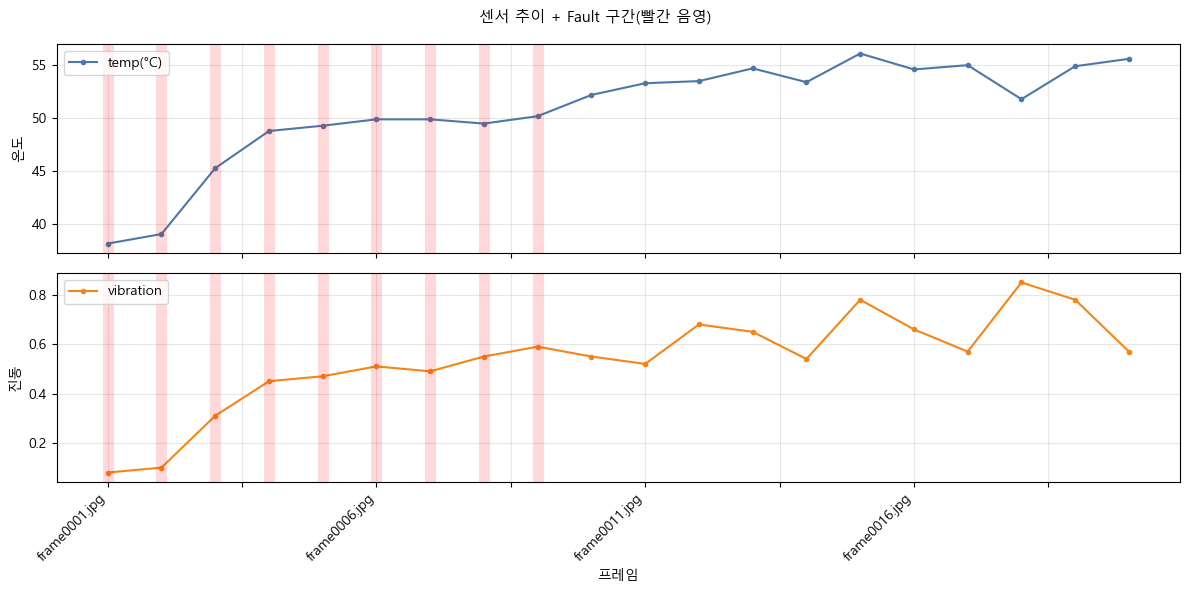

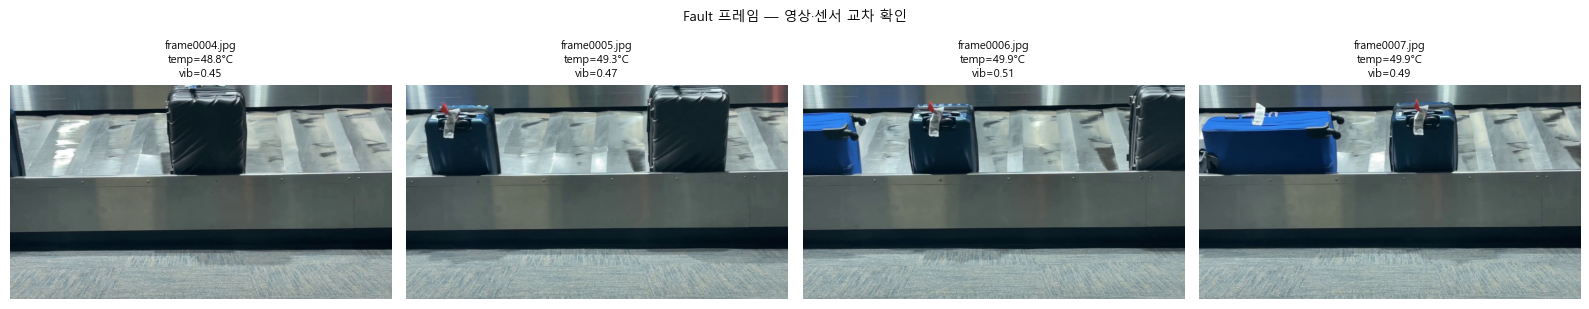

In [7]:
# --- 3-5. 시각·센서 교차 검증 차트 ---
if not join_df.empty:
    fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

    plot_df = join_df.set_index("frame")
    plot_df["temp"].plot(ax=axes[0], marker="o", ms=3, color="#4C78A8", label="temp(°C)")
    axes[0].set_ylabel("온도")
    axes[0].legend(loc="upper left")
    axes[0].grid(alpha=0.3)

    plot_df["vibration"].plot(ax=axes[1], marker="o", ms=3, color="#F58518", label="vibration")
    axes[1].set_ylabel("진동")
    axes[1].set_xlabel("프레임")
    axes[1].legend(loc="upper left")
    axes[1].grid(alpha=0.3)

    # Fault 구간 강조 — 센서 이상 구간을 시각적으로 표시
    fault_frames = join_df[join_df["status"] == "Fault"]["frame"]
    for ax in axes:
        for ff in fault_frames:
            ax.axvline(ff, color="red", alpha=0.15, linewidth=8)
    plt.suptitle("센서 추이 + Fault 구간(빨간 음영)", fontsize=11)
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

# Fault 프레임 썸네일 + 센서 수치 — 영상·계측 데이터 교차 확인
fault_rows = join_df[join_df["status"] == "Fault"].head(4)
if not fault_rows.empty:
    fig, axes = plt.subplots(1, len(fault_rows), figsize=(4 * len(fault_rows), 3.5))
    if len(fault_rows) == 1:
        axes = [axes]
    for ax, (_, row) in zip(axes, fault_rows.iterrows()):
        img_path = Path(row["image_path"])
        if img_path.exists():
            ax.imshow(Image.open(img_path))
        ax.set_title(
            f"{row['frame']}\ntemp={row['temp']}°C\nvib={row['vibration']}",
            fontsize=8,
        )
        ax.axis("off")
    plt.suptitle("Fault 프레임 — 영상·센서 교차 확인", fontsize=10)
    plt.tight_layout()
    plt.show()

In [8]:
# --- 3-6. 검색 API — 센서 메타 enrichment 확인 ---
# POST /search 응답에 sensor 키가 별도로 포함되는지 검증 (enrich_hits_with_sensor)
if conveyor_health:
    search_resp = requests.post(
        f"{CONVEYOR_API}/search",
        json={"query": "컨베이어 벨트 이상 상태", "top_k": 4},
        timeout=API_TIMEOUT_SEARCH,
    ).json()

    rows = []
    for hit in search_resp.get("results", []):
        meta = hit["metadata"]
        sensor = hit.get("sensor", meta)  # enrichment 실패 시 metadata 폴백
        rows.append({
            "frame": meta.get("frame"),
            "similarity": round(hit["similarity"], 3),
            "status": sensor.get("status"),
            "temp": sensor.get("temp"),
            "vibration": sensor.get("vibration"),
            "sensor_enriched": "sensor" in hit,
        })
    df_search = pd.DataFrame(rows)
    print(f"검색 결과 {len(df_search)}건 | sensor 키 포함: {df_search['sensor_enriched'].all()}")
    display(df_search)
else:
    print("Conveyor API 미실행 — 검색·센서 연계 테스트 건너뜀")

Conveyor API 미실행 — 검색·센서 연계 테스트 건너뜀


## 4. 엔드투엔드 API 통합 체크리스트

Streamlit UI가 호출하는 주요 엔드포인트를 노트북에서 일괄 검증합니다.


In [9]:
def run_integration_checklist() -> pd.DataFrame:
    """Streamlit UI가 호출하는 주요 API를 일괄 호출해 성공 여부를 기록."""
    results = []

    def add(name, service, ok, detail=""):
        results.append({"항목": name, "서비스": service, "성공": ok, "상세": detail})

    # Conveyor — 검색·센서·메타·이력
    if conveyor_health:
        try:
            r = requests.post(f"{CONVEYOR_API}/search", json={"query": "belt fault", "top_k": 2}, timeout=API_TIMEOUT_SEARCH).json()
            add("텍스트 검색", "Conveyor", bool(r.get("results")), f"{len(r.get('results', []))}건")
        except Exception as e:
            add("텍스트 검색", "Conveyor", False, str(e)[:60])
        try:
            r = requests.get(f"{CONVEYOR_API}/sensor", params={"frame": "frame0004.jpg"}, timeout=API_TIMEOUT).json()
            add("센서 조회", "Conveyor", "temp" in r, f"status={r.get('status')}")
        except Exception as e:
            add("센서 조회", "Conveyor", False, str(e)[:60])
        try:
            r = requests.get(f"{CONVEYOR_API}/metadata/frames", timeout=API_TIMEOUT).json()
            add("프레임·센서 조인", "Conveyor", r.get("count", 0) > 0, f"{r.get('count')}건")
        except Exception as e:
            add("프레임·센서 조인", "Conveyor", False, str(e)[:60])
        try:
            r = requests.get(f"{CONVEYOR_API}/history", params={"limit": 3}, timeout=API_TIMEOUT).json()
            add("분석 이력", "Conveyor", "history" in r, f"{len(r.get('history', []))}건")
        except Exception as e:
            add("분석 이력", "Conveyor", False, str(e)[:60])
    else:
        add("Conveyor API", "Conveyor", False, "미실행")

    # MVTec — 통계·조회·유사검색·품목
    if mvtec_health:
        try:
            r = requests.get(f"{MVTEC_API}/stats", timeout=API_TIMEOUT).json()
            add("불량 통계", "MVTec", "defect_rate" in r, f"불량률 {r.get('defect_rate')}%")
        except Exception as e:
            add("불량 통계", "MVTec", False, str(e)[:60])
        try:
            r = requests.get(f"{MVTEC_API}/inspections", params={"label": "불량", "limit": 3}, timeout=API_TIMEOUT).json()
            add("검사 조회", "MVTec", r.get("count", 0) >= 0, f"{r.get('count')}건")
        except Exception as e:
            add("검사 조회", "MVTec", False, str(e)[:60])
        try:
            r = requests.post(f"{MVTEC_API}/search", json={"query": "crack defect", "product": "bottle", "top_k": 3}, timeout=API_TIMEOUT_SEARCH).json()
            add("유사 이미지 검색", "MVTec", bool(r.get("results")), f"{len(r.get('results', []))}건")
        except Exception as e:
            add("유사 이미지 검색", "MVTec", False, str(e)[:60])
        try:
            r = requests.get(f"{MVTEC_API}/products", timeout=API_TIMEOUT).json()
            add("품목 목록", "MVTec", len(r.get("products", [])) == 15, f"{len(r.get('products', []))}개")
        except Exception as e:
            add("품목 목록", "MVTec", False, str(e)[:60])
    else:
        add("MVTec API", "MVTec", False, "미실행")

    df = pd.DataFrame(results)
    passed = int(df["성공"].sum())
    print(f"체크리스트: {passed}/{len(df)} 통과")
    return df

checklist_df = run_integration_checklist()

def _highlight_checklist(row):
    # axis=1: 행마다 '성공' 값에 따라 동일 배경색을 모든 열에 적용
    bg = "background-color: #d4edda" if row["성공"] else "background-color: #f8d7da"
    return [bg] * len(row)

display(checklist_df.style.apply(_highlight_checklist, axis=1))

체크리스트: 0/2 통과


,항목,서비스,성공,상세
0,Conveyor API,Conveyor,False,미실행
1,MVTec API,MVTec,False,미실행


## 5. 피드백 수집 · 반영

웹 서비스 사용 후 **평점·코멘트**를 JSON에 저장하고, 낮은 평점 항목에 **개선 권고**를 자동 생성합니다.

| 필드 | 설명 |
|------|------|
| `service` | Conveyor / MVTec |
| `endpoint` | `/search`, `/upload` 등 |
| `rating` | 1~5 (5=만족) |
| `comment` | 사용자 의견 |
| `context` | 질의·프레임·품목 등 맥락 |


In [10]:
def load_feedback() -> list[dict]:
    """피드백 JSON 파일 로드 — 없으면 빈 리스트."""
    if FEEDBACK_JSON.exists():
        return json.loads(FEEDBACK_JSON.read_text(encoding="utf-8"))
    return []


def save_feedback(records: list[dict]) -> None:
    """피드백 전체 목록을 JSON 파일에 덮어쓰기."""
    FEEDBACK_JSON.write_text(json.dumps(records, ensure_ascii=False, indent=2), encoding="utf-8")


def submit_feedback(
    service: str,
    endpoint: str,
    rating: int,
    comment: str = "",
    context: dict | None = None,
) -> dict:
    """피드백 1건 추가 후 JSON 저장."""
    records = load_feedback()
    entry = {
        "id": str(uuid.uuid4())[:8],
        "timestamp": datetime.now(timezone.utc).isoformat(),
        "service": service,       # Conveyor / MVTec
        "endpoint": endpoint,     # /search, /upload 등
        "rating": max(1, min(5, rating)),  # 1~5 클리핑
        "comment": comment,
        "context": context or {},  # 질의·프레임·품목 등 맥락
    }
    records.append(entry)
    save_feedback(records)
    return entry


def reflect_feedback(min_samples: int = 1) -> pd.DataFrame:
    """저장된 피드백을 분석해 서비스별 개선 권고 생성."""
    records = load_feedback()
    if len(records) < min_samples:
        return pd.DataFrame([{"상태": "피드백 없음", "권고": "submit_feedback()으로 의견을 먼저 수집하세요."}])

    df = pd.DataFrame(records)
    recommendations = []

    for service in df["service"].unique():
        sub = df[df["service"] == service]
        avg_rating = sub["rating"].mean()
        low = sub[sub["rating"] <= 2]  # 낮은 평점만 개선 대상

        if avg_rating < 3.5:
            recommendations.append({
                "서비스": service,
                "평균평점": round(avg_rating, 2),
                "건수": len(sub),
                "권고": "전반적 만족도 낮음 — API 응답 시간·에러 메시지·UI 안내 문구 점검",
            })

        for ep in low["endpoint"].unique():
            ep_low = low[low["endpoint"] == ep]
            rec = {
                "서비스": service,
                "평균평점": round(ep_low["rating"].mean(), 2),
                "건수": len(ep_low),
                "권고": f"{ep} 개선 필요",
            }
            # 엔드포인트별 구체적 개선 방향 — 이전 실습 노트북과 연계
            if ep == "/search" and service == "MVTec":
                rec["권고"] += " — 08 노트북 Top-K·Threshold 튜닝 검토"
            elif ep == "/search" and service == "Conveyor":
                rec["권고"] += " — ChromaDB 인덱스·센서 메타 동기화 재확인"
            elif ep == "/analyze":
                rec["권고"] += " — Qwen3-VL 프롬프트·top_k 축소 또는 GPU 메모리 확인"
            elif ep == "/upload":
                rec["권고"] += " — SigLIP2 판정 임계값·유사 검색 top_k 조정"
            recommendations.append(rec)

        # 긍정 피드백 반영
        high = sub[sub["rating"] >= 4]
        if len(high) >= 2:
            recommendations.append({
                "서비스": service,
                "평균평점": round(high["rating"].mean(), 2),
                "건수": len(high),
                "권고": "우수 응답 패턴 유지 — 현재 검색·분석 설정을 기본값으로 문서화",
            })

    if not recommendations:
        recommendations.append({
            "서비스": "전체",
            "평균평점": round(df["rating"].mean(), 2),
            "건수": len(df),
            "권고": "피드백 양호 — 정기 모니터링 유지",
        })

    return pd.DataFrame(recommendations)

print(f"피드백 저장 경로: {FEEDBACK_JSON}")

피드백 저장 경로: C:\MyCursorLab\09_Visual_RAG\data\integration\service_feedback.json


In [11]:
# --- 체크리스트 결과·센서 테스트 기반 샘플 피드백 등록 ---
# 실제 Streamlit 사용 후 사용자가 입력한 값으로 교체 가능

if conveyor_health and not join_df.empty:
    submit_feedback(
        service="Conveyor",
        endpoint="/search",
        rating=4,
        comment="Fault 프레임 검색은 잘 되나 Warning 구간 정밀도 개선 필요",
        context={"query": "컨베이어 벨트 이상 상태", "fault_frames": int((join_df["status"] == "Fault").sum())},
    )
    submit_feedback(
        service="Conveyor",
        endpoint="/metadata/verify",
        rating=5 if count_ok else 2,
        comment="센서·영상 동기화" + (" 정상" if count_ok else " 불일치 발견"),
        context={"frame_count": len(frame_files), "sensor_rows": len(sensor_df)},
    )

if mvtec_health:
    submit_feedback(
        service="MVTec",
        endpoint="/search",
        rating=3,
        comment="유사 결함 검색 useful — 08 노트북 Threshold 0.7 적용 검토",
        context={"product": "bottle", "top_k": 5},
    )
    submit_feedback(
        service="MVTec",
        endpoint="/stats",
        rating=5,
        comment="품목별 불량률 대시보드 직관적",
        context={"defect_rate": mvtec_health.get("defect_rate")},
    )

# 낮은 평점 시뮬레이션 (개선 권고 테스트용)
submit_feedback(
    service="Conveyor",
    endpoint="/analyze",
    rating=2,
    comment="Qwen3-VL 응답이 느림 — top_k=1 권장",
    context={"top_k": 3, "timeout_sec": 900},
)

print(f"피드백 {len(load_feedback())}건 저장됨")
display(pd.DataFrame(load_feedback())[["id", "service", "endpoint", "rating", "comment"]].tail(6))

피드백 4건 저장됨


,id,service,endpoint,rating,comment
0,17f2b79e,Conveyor,/analyze,2,Qwen3-VL 응답이 느림 — top_k=1 권장
1,3d0dbe3c,Conveyor,/analyze,2,Qwen3-VL 응답이 느림 — top_k=1 권장
2,63aaa14c,Conveyor,/analyze,2,Qwen3-VL 응답이 느림 — top_k=1 권장
3,7867f12f,Conveyor,/analyze,2,Qwen3-VL 응답이 느림 — top_k=1 권장


### 피드백 기반 개선 권고

,서비스,평균평점,건수,권고
0,Conveyor,2.0,4,전반적 만족도 낮음 — API 응답 시간·에러 메시지·UI 안내 문구 점검
1,Conveyor,2.0,4,/analyze 개선 필요 — Qwen3-VL 프롬프트·top_k 축소 또는 GPU...


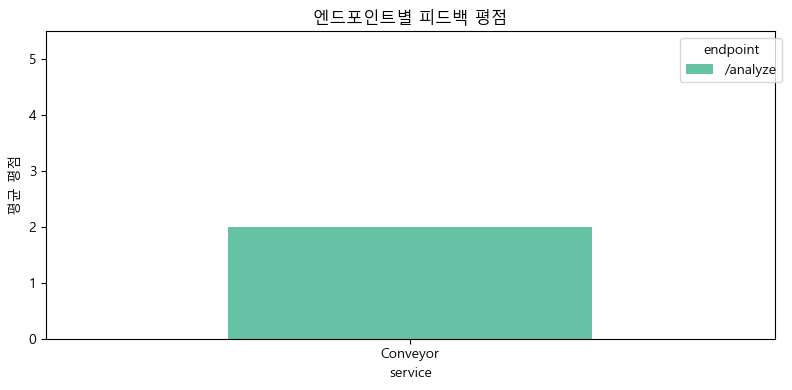

In [12]:
# --- 피드백 반영: 개선 권고표 ---
rec_df = reflect_feedback()
display(Markdown("### 피드백 기반 개선 권고"))
display(rec_df)

# 서비스별·엔드포인트별 평균 평점 막대 차트
fb_df = pd.DataFrame(load_feedback())
if not fb_df.empty:
    fig, ax = plt.subplots(figsize=(8, 4))
    fb_df.groupby(["service", "endpoint"])["rating"].mean().unstack(fill_value=0).plot(
        kind="bar", ax=ax, rot=0, colormap="Set2"
    )
    ax.set_ylabel("평균 평점")
    ax.set_title("엔드포인트별 피드백 평점")
    ax.set_ylim(0, 5.5)
    ax.legend(title="endpoint", bbox_to_anchor=(1.02, 1))
    plt.tight_layout()
    plt.show()

## 6. 통합 엔드투엔드 시나리오

실제 운영 흐름을 시뮬레이션합니다.

```
[Conveyor] 센서 Fault 감지 → 영상 프레임 검색 → (선택) Qwen 분석
       ↓
[MVTec]    유사 결함 이미지 검색 → 검사 이력·불량률 확인
       ↓
[피드백]   사용 결과 평가 → JSON 저장 → 개선 권고
```


In [13]:
scenario_log = []

# Step 1: Conveyor — Fault 센서 프레임 API 조회 후 유사 영상 검색
if conveyor_health and not join_df.empty:
    fault_frame = join_df[join_df["status"] == "Fault"].iloc[0]["frame"]
    sensor_row = requests.get(f"{CONVEYOR_API}/sensor", params={"frame": fault_frame}, timeout=API_TIMEOUT).json()
    scenario_log.append(f"1. Conveyor 센서 Fault: {fault_frame} temp={sensor_row.get('temp')}°C")

    search_r = requests.post(
        f"{CONVEYOR_API}/search",
        json={"query": "벨트 손상 이상", "top_k": 3},
        timeout=API_TIMEOUT_SEARCH,
    ).json()
    top_frame = search_r["results"][0]["metadata"]["frame"] if search_r.get("results") else "N/A"
    scenario_log.append(f"2. Conveyor 검색 Top-1: {top_frame}")

# Step 2: MVTec — 유사 결함 검색 + 품목별 불량률
if mvtec_health:
    mv_search = requests.post(
        f"{MVTEC_API}/search",
        json={"query": "surface crack defect", "product": "bottle", "top_k": 3},
        timeout=API_TIMEOUT_SEARCH,
    ).json()
    if mv_search.get("results"):
        hit = mv_search["results"][0]["metadata"]
        scenario_log.append(f"3. MVTec 유사검색: {hit.get('product')}/{hit.get('defect_type')}")

    stats = requests.get(f"{MVTEC_API}/stats", params={"product": "bottle"}, timeout=API_TIMEOUT).json()
    scenario_log.append(f"4. MVTec bottle 불량률: {stats.get('defect_rate')}%")

# Step 3: 피드백 반영 — 앞선 테스트 결과를 권고표로 연결
scenario_log.append(f"5. 피드백 {len(load_feedback())}건 → 권고 {len(rec_df)}항목")

for line in scenario_log:
    print(line)

display(Markdown("**통합 시나리오 완료** — Streamlit UI에서 동일 흐름을 버튼 클릭으로 수행할 수 있습니다."))

5. 피드백 4건 → 권고 2항목


**통합 시나리오 완료** — Streamlit UI에서 동일 흐름을 버튼 클릭으로 수행할 수 있습니다.

## 7. Streamlit 웹 UI 동시 운영

| 터미널 | 명령 | URL |
|--------|------|-----|
| 1 | `cd conveyor_analyze && python scripts/run_api.py` | http://127.0.0.1:8000 |
| 2 | `cd mvtec_analyze && python scripts/run_api.py` | http://127.0.0.1:8002 |
| 3 | `streamlit run conveyor_analyze/dashboard/streamlit_app.py` | http://127.0.0.1:8501 |
| 4 | `streamlit run mvtec_analyze/dashboard/streamlit_app.py --server.port 8502` | http://127.0.0.1:8502 |

> 두 Streamlit을 동시에 띄울 때 MVTec는 `--server.port 8502`로 포트 분리


In [14]:
print("=== 서비스 실행 가이드 ===\n")
print("터미널 1 — Conveyor API")
print(f"  cd {CONVEYOR_ANALYZE}")
print("  python scripts/run_api.py\n")
print("터미널 2 — MVTec API")
print(f"  cd {MVTEC_ANALYZE}")
print("  python scripts/run_api.py\n")
print("터미널 3 — Conveyor Streamlit")
print(f"  streamlit run {CONVEYOR_STREAMLIT}\n")
print("터미널 4 — MVTec Streamlit (포트 8502)")
print(f"  streamlit run {MVTEC_STREAMLIT} --server.port 8502\n")

# 현재 포트 점유 상태 — ✓ 실행 중 / ○ 미실행
ports = {
    "Conveyor API (8000)": port_open(8000),
    "MVTec API (8002)": port_open(8002),
    "Streamlit (8501)": port_open(8501),
    "Streamlit MVTec (8502)": port_open(8502),
}
for name, ok in ports.items():
    print(f"  {'✓' if ok else '○'} {name}: {'실행 중' if ok else '미실행'}")

=== 서비스 실행 가이드 ===

터미널 1 — Conveyor API
  cd C:\MyCursorLab\09_Visual_RAG\conveyor_analyze
  python scripts/run_api.py

터미널 2 — MVTec API
  cd C:\MyCursorLab\09_Visual_RAG\mvtec_analyze
  python scripts/run_api.py

터미널 3 — Conveyor Streamlit
  streamlit run C:\MyCursorLab\09_Visual_RAG\conveyor_analyze\dashboard\streamlit_app.py

터미널 4 — MVTec Streamlit (포트 8502)
  streamlit run C:\MyCursorLab\09_Visual_RAG\mvtec_analyze\dashboard\streamlit_app.py --server.port 8502

  ○ Conveyor API (8000): 미실행
  ○ MVTec API (8002): 미실행
  ○ Streamlit (8501): 미실행
  ○ Streamlit MVTec (8502): 미실행


## 8. 정리

| 학습 포인트 | 내용 |
|-------------|------|
| **듀얼 서비스** | Conveyor(센서·영상 VQA) + MVTec(결함 검사) API 포트 분리 운영 |
| **센서·영상 통합** | frame 키 조인 · Chroma 동기화 · Fault 구간 시각·수치 교차 검증 |
| **통합 체크리스트** | Streamlit이 쓰는 API를 노트북에서 일괄 검증 |
| **피드백 루프** | JSON 저장 → 평점 분석 → 08번 Threshold 등 개선 권고 반영 |
| **운영** | API 2 + Streamlit 2 터미널 동시 기동 |

> **시리즈 완료**: `01`~`09` — Visual RAG 기초 → 컨베이어 VQA → MVTec 검사 → 검색 성능 평가 → **통합·피드백**
